In [1]:
import os
# disable oneDNN optimizations and silences most TF log messages
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL']   = '2'

import random
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import tarfile
import urllib.request
import pickle

# Import sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Import keras helpers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.losses import CategoricalCrossentropy

2025-04-22 00:05:16.286833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745294716.307998 2517444 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745294716.314313 2517444 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745294716.330178 2517444 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745294716.330195 2517444 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745294716.330197 2517444 computation_placer.cc:177] computation placer alr

In [2]:
# set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# define directory layout
DATA_RAW_DIR       = "data/raw"
DATA_PROCESSED_DIR = "data/processed"
FIGURES_DIR        = "outputs/figures"
MODELS_DIR         = "outputs/models"
RESULTS_DIR        = "results"

In [4]:
# create directories if they don't exist
for d in [DATA_RAW_DIR, DATA_PROCESSED_DIR, FIGURES_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

In [6]:
# download CIFAR-10 if not already downloaded
cifar10_url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
cifar10_archive = os.path.join(DATA_RAW_DIR, "cifar-10-python.tar.gz")
cifar10_dir = os.path.join(DATA_RAW_DIR, "cifar-10-batches-py")

if not os.path.exists(cifar10_dir):
    print("Downloading CIFAR-10 dataset...")
    urllib.request.urlretrieve(cifar10_url, cifar10_archive)

    print("Extracting archive...")
    with tarfile.open(cifar10_archive, "r:gz") as tar:
        tar.extractall(path=DATA_RAW_DIR)
else:
    print("CIFAR-10 already exists.")

Extracting archive...


In [8]:
def load_cifar_batch(filepath):
    with open(filepath, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
        x = batch[b'data']
        y = batch[b'labels']
        x = x.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # convert to (N, 32, 32, 3)
        y = np.array(y)
        return x, y

# load all training batches
x_train_list, y_train_list = [], []
for i in range(1, 6):
    batch_path = os.path.join(DATA_RAW_DIR, "cifar-10-batches-py", f"data_batch_{i}")
    x_batch, y_batch = load_cifar_batch(batch_path)
    x_train_list.append(x_batch)
    y_train_list.append(y_batch)

x_train_orig = np.concatenate(x_train_list, axis=0)
y_train_orig = np.concatenate(y_train_list, axis=0)

# load test batch
test_batch_path = os.path.join(DATA_RAW_DIR, "cifar-10-batches-py", "test_batch")
x_test_orig, y_test_orig = load_cifar_batch(test_batch_path)

print(f"x_train_orig: {x_train_orig.shape}, y_train_orig: {y_train_orig.shape}")
print(f"x_test_orig:  {x_test_orig.shape},  y_test_orig:  {y_test_orig.shape}")

x_train_orig: (50000, 32, 32, 3), y_train_orig: (50000,)
x_test_orig:  (10000, 32, 32, 3),  y_test_orig:  (10000,)


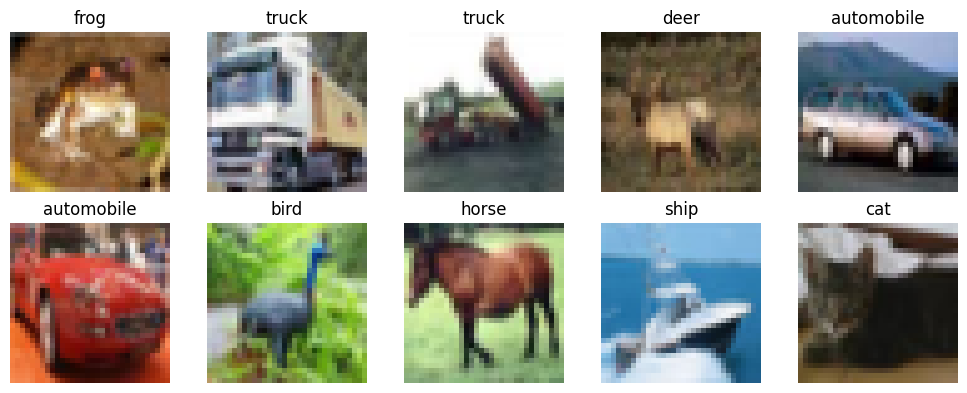

In [9]:
# load class names from meta
with open(os.path.join(DATA_RAW_DIR, "cifar-10-batches-py", "batches.meta"), 'rb') as f:
    label_names = pickle.load(f, encoding='bytes')[b'label_names']
    class_names = [name.decode("utf-8") for name in label_names]

# plot 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train_orig[i])
    ax.set_title(class_names[y_train_orig[i]])
    ax.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "sample_images.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

In [10]:
# split train/val and save processed datasets
x_train, x_val, y_train, y_val = train_test_split(
    x_train_orig, 
    y_train_orig, 
    test_size=0.10,
    stratify=y_train_orig,
    random_state=42, 
    shuffle=True
)
x_test, y_test = x_test_orig, y_test_orig

# save splits as compressed npz for reproducibility
np.savez_compressed(
    os.path.join(DATA_PROCESSED_DIR, "train.npz"),
    x=x_train, y=y_train
)
np.savez_compressed(
    os.path.join(DATA_PROCESSED_DIR, "val.npz"),
    x=x_val, y=y_val
)
np.savez_compressed(
    os.path.join(DATA_PROCESSED_DIR, "test.npz"),
    x=x_test, y=y_test
)

# sanity‑check
print(f"train: {x_train.shape, y_train.shape}")
print(f"val:   {x_val.shape,   y_val.shape}")
print(f"test:  {x_test.shape,  y_test.shape}")

train: ((45000, 32, 32, 3), (45000,))
val:   ((5000, 32, 32, 3), (5000,))
test:  ((10000, 32, 32, 3), (10000,))


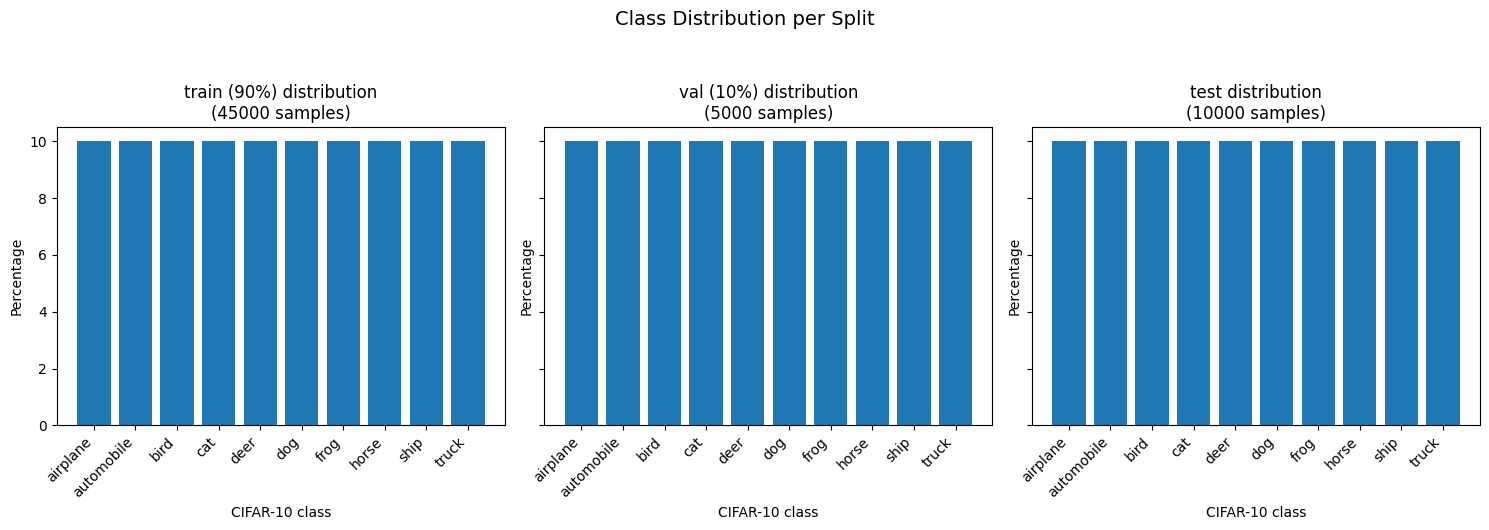

In [11]:
# visualize and save class distributions for train, val, and test
num_classes = len(class_names)

train_labels = y_train
val_labels   = y_val
test_labels  = y_test

# count occurrences per class
train_counts = np.bincount(train_labels, minlength=num_classes)
val_counts   = np.bincount(val_labels,   minlength=num_classes)
test_counts  = np.bincount(test_labels,  minlength=num_classes)

# convert to percentages per split
train_pct = train_counts / train_counts.sum() * 100
val_pct   = val_counts   / val_counts.sum()   * 100
test_pct  = test_counts  / test_counts.sum()  * 100

# split sizes and their overall ratios
split_info = [
    ("train (90%)", train_counts.sum()),
    ("val (10%)",   val_counts.sum()),
    ("test",        test_counts.sum())
]

# plot side-by-side bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, pct, (title, count) in zip(
    axes,
    [train_pct, val_pct, test_pct],
    split_info
):
    ax.bar(range(num_classes), pct)
    ax.set_title(f"{title} distribution\n({count} samples)")
    ax.set_xlabel("CIFAR-10 class")
    ax.set_ylabel("Percentage")
    ax.set_xticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=45, ha="right")

fig.suptitle("Class Distribution per Split", fontsize=14, y=1.05)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "class_distribution.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

In [5]:
# data generator parameters
IMAGE_WIDTH   = 32
IMAGE_HEIGHT  = 32
IMAGE_DEPTH   = 3
BATCH_SIZE    = 64
NUM_CLASSES   = 10

# load processed splits
train_npz = np.load(os.path.join(DATA_PROCESSED_DIR, "train.npz"))
val_npz   = np.load(os.path.join(DATA_PROCESSED_DIR, "val.npz"))
test_npz  = np.load(os.path.join(DATA_PROCESSED_DIR, "test.npz"))

x_train, y_train = train_npz["x"], train_npz["y"]
x_val,   y_val   = val_npz["x"],   val_npz["y"]
x_test,  y_test  = test_npz["x"],  test_npz["y"]

# one‑hot encode labels
y_train = to_categorical(y_train, NUM_CLASSES)
y_val   = to_categorical(y_val,   NUM_CLASSES)
y_test  = to_categorical(y_test,  NUM_CLASSES)

# create image data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# build generators
train_generator = train_datagen.flow(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)
validation_generator = val_datagen.flow(
    x_val,
    y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_generator = test_datagen.flow(
    x_test,
    y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [6]:
os.environ["CUDA_VISIBLE_DEVICES"] = "2" 

In [12]:
# model and head hyperparameters
PRE_TRAIN_WIDTH    = 224
PRE_TRAIN_HEIGHT   = 224
NUM_CLASSES        = 10
HEAD_UNITS_1       = 256
HEAD_UNITS_2       = 128
L2_WEIGHT_DECAY    = 1e-5
DROPOUT_RATE       = 0.3
INITIAL_LR         = 1e-3
LABEL_SMOOTHING    = 0.05
CLASS_NAMES        = [str(i) for i in range(NUM_CLASSES)]

def build_model():
    # load mobilenetv2 feature extractor
    base = tf.keras.applications.MobileNetV2(
        input_shape=(PRE_TRAIN_HEIGHT, PRE_TRAIN_WIDTH, 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False

    # cifar-10 input
    inp = tf.keras.Input((IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_DEPTH))
    # resize to mobilenet input
    x = tf.keras.layers.Resizing(PRE_TRAIN_HEIGHT, PRE_TRAIN_WIDTH)(inp)
    # feature extraction
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # head block 1
    x = tf.keras.layers.Dense(
        HEAD_UNITS_1,
        kernel_regularizer=regularizers.l2(L2_WEIGHT_DECAY),
        use_bias=False
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE)(x)

    # head block 2
    x = tf.keras.layers.Dense(
        HEAD_UNITS_2,
        kernel_regularizer=regularizers.l2(L2_WEIGHT_DECAY),
        use_bias=False
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(DROPOUT_RATE)(x)

    # output layer
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    # compile
    model = tf.keras.Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=INITIAL_LR),
        loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=["accuracy"]
    )
    return model, base

# build and summarize
model, base_model = build_model()
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,258 (10.00 MB)

 Trainable params: 362,506 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

In [13]:
# pretraining parameters
EPOCHS = 30

def train_model():
    # early stop on val_accuracy stagnation
    es = EarlyStopping(
        monitor="val_accuracy",
        min_delta=8e-05,
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    # lr reduction on plateau
    rlrop = ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.25,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
    # train model
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=EPOCHS,
        steps_per_epoch=len(train_generator),
        validation_steps=len(validation_generator),
        callbacks=[es, rlrop],
        verbose=1
    )
    return history

# run pretraining
hist = train_model()

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 70ms/step - accuracy: 0.5631 - loss: 1.4068 - val_accuracy: 0.7762 - val_loss: 0.8721 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.6771 - loss: 1.1063 - val_accuracy: 0.7760 - val_loss: 0.8635 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.7062 - loss: 1.0521 - val_accuracy: 0.7878 - val_loss: 0.8267 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.7074 - loss: 1.0427 - val_accuracy: 0.7948 - val_loss: 0.8146 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.7162 - loss: 1.0168 - val_accuracy: 0.7930 - val_loss: 0.8161 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/step - accuracy: 0.7232 - loss: 1.0039 - val_accuracy: 0.8090 - val_loss: 0.7931 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.7317 - l

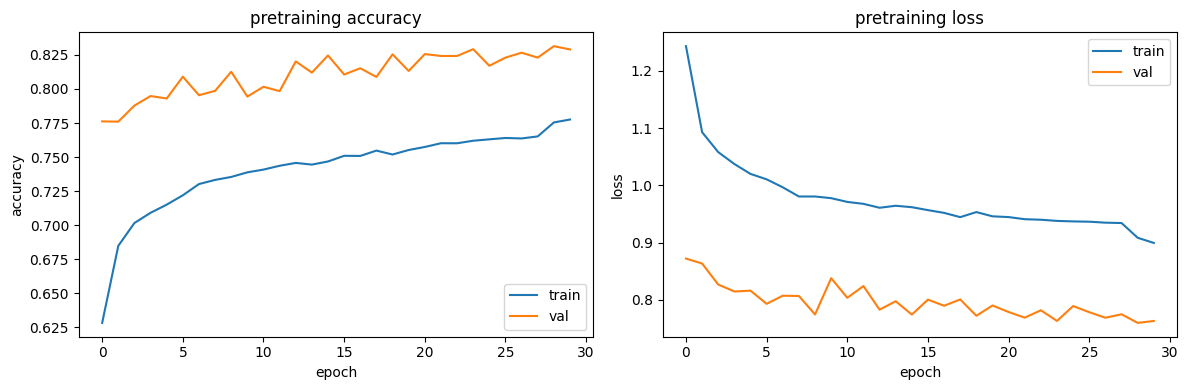

In [14]:
# visualize and save pretraining history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# accuracy
axes[0].plot(hist.history['accuracy'], label='train')
axes[0].plot(hist.history['val_accuracy'], label='val')
axes[0].set_title('pretraining accuracy')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend(loc='lower right')

# loss
axes[1].plot(hist.history['loss'], label='train')
axes[1].plot(hist.history['val_loss'], label='val')
axes[1].set_title('pretraining loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "pretraining_history.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

/home/jupyter-noz224/.conda/envs/MNIST/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step
accuracy         : 0.8245
f1 (macro)       : 0.8232
f1 (weighted)    : 0.8232
auc‑roc (macro)  : 0.9848
auc‑roc (micro)  : 0.9853

classification report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1000
           1       0.91      0.91      0.91      1000
           2       0.82      0.75      0.79      1000
           3       0.77      0.66      0.71      1000
           4       0.81      0.74      0.78      1000
           5       0.83      0.72      0.77      1000
           6       0.70      0.94      0.80      1000
           7       0.80      0.87      0.84      1000
           8       0.91      0.87      0.89      1000
           9       0.86      0.93      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



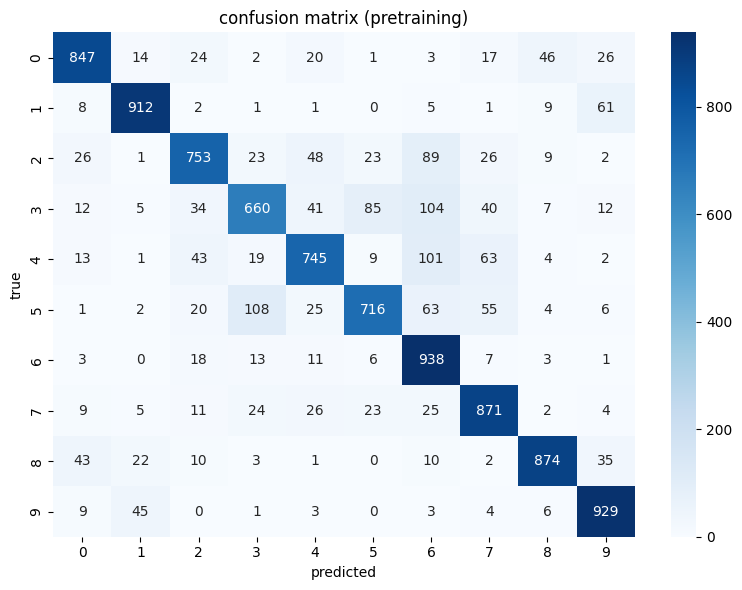

In [15]:
# evaluate pretrained model on test set
y_pred_prob = model.predict(test_generator)
y_true      = np.argmax(y_test, axis=1)
y_pred      = np.argmax(y_pred_prob, axis=1)

# compute basic metrics
acc          = accuracy_score(y_true, y_pred)
f1_macro     = f1_score(y_true, y_pred, average='macro')
f1_weighted  = f1_score(y_true, y_pred, average='weighted')

# compute multiclass auc‑roc
y_bin        = to_categorical(y_true, NUM_CLASSES)
auc_macro    = roc_auc_score(y_bin, y_pred_prob, multi_class='ovr', average='macro')
auc_micro    = roc_auc_score(y_bin, y_pred_prob, multi_class='ovr', average='micro')

# print summary
print(f"accuracy         : {acc:.4f}")
print(f"f1 (macro)       : {f1_macro:.4f}")
print(f"f1 (weighted)    : {f1_weighted:.4f}")
print(f"auc‑roc (macro)  : {auc_macro:.4f}")
print(f"auc‑roc (micro)  : {auc_micro:.4f}\n")

# detailed classification report
print("classification report:")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    zero_division=0
))

# plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('predicted')
plt.ylabel('true')
plt.title('confusion matrix (pretraining)')
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "confusion_matrix_pretrain.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

In [16]:
# save final fine‑tuned model
final_model_path = os.path.join(MODELS_DIR, "mobilenet.keras")
model.save(final_model_path)
print(f"saved fine‑tuned model to {final_model_path}")

saved fine‑tuned model to outputs/models/mobilenet.keras


In [19]:
# fine‑tuning parameters
FINE_TUNE_EPOCHS = 40

def fine_tune_model():
    # unfreeze last 20 layers of the base model
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    # recompile with low lr, weight decay, and label smoothing
    model.compile(
        optimizer=AdamW(learning_rate=5e-6, weight_decay=L2_WEIGHT_DECAY),
        loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=["accuracy"]
    )

    # early stop on val_accuracy
    es = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    # reduce lr on plateau
    rlrop = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )

    # continue training for fine‑tune epochs
    history_ft = model.fit(
        train_generator,
        validation_data=validation_generator,
        initial_epoch=hist.epoch[-1] + 1,
        epochs=hist.epoch[-1] + 1 + FINE_TUNE_EPOCHS,
        steps_per_epoch=len(train_generator),
        validation_steps=len(validation_generator),
        callbacks=[es, rlrop],
        verbose=1
    )
    return history_ft

# run fine‑tuning
hist_ft = fine_tune_model()

Epoch 31/70
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 77ms/step - accuracy: 0.8020 - loss: 0.8410 - val_accuracy: 0.8514 - val_loss: 0.7122 - learning_rate: 5.0000e-06
Epoch 32/70
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.8100 - loss: 0.8271 - val_accuracy: 0.8522 - val_loss: 0.7118 - learning_rate: 5.0000e-06
Epoch 33/70
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.8067 - loss: 0.8331 - val_accuracy: 0.8504 - val_loss: 0.7142 - learning_rate: 5.0000e-06
Epoch 34/70
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8104 - loss: 0.8258
Epoch 34: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.8104 - loss: 0.8258 - val_accuracy: 0.8518 - val_loss: 0.7120 - learning_rate: 5.0000e-06
Epoch 35/70
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.8173 - loss: 0.8119 - val_accuracy: 0.8538 - val_loss: 0.7075 - learning_rate: 1.0000e-06
Epoch 36/70
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 51ms/st

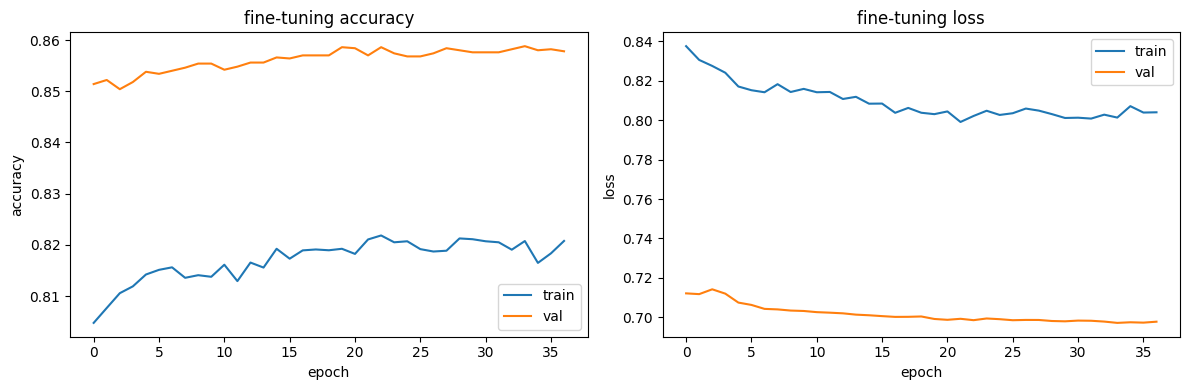

In [20]:
# visualize and save fine‑tuning history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# accuracy
axes[0].plot(hist_ft.history['accuracy'], label='train')
axes[0].plot(hist_ft.history['val_accuracy'], label='val')
axes[0].set_title('fine‑tuning accuracy')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend(loc='lower right')

# loss
axes[1].plot(hist_ft.history['loss'], label='train')
axes[1].plot(hist_ft.history['val_loss'], label='val')
axes[1].set_title('fine‑tuning loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "finetuning_history.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step
final accuracy        : 0.8554
final f1 (macro)      : 0.8543
final f1 (weighted)   : 0.8543
final auc‑roc (macro) : 0.9882
final auc‑roc (micro) : 0.9890

final classification report:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      1000
           1       0.92      0.95      0.93      1000
           2       0.82      0.80      0.81      1000
           3       0.81      0.70      0.75      1000
           4       0.84      0.80      0.81      1000
           5       0.84      0.77      0.81      1000
           6       0.75      0.95      0.84      1000
           7       0.87      0.89      0.88      1000
           8       0.93      0.91      0.92      1000
           9       0.89      0.95      0.92      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.85     10000
weighted avg       0.86      0.86      0.85     10000



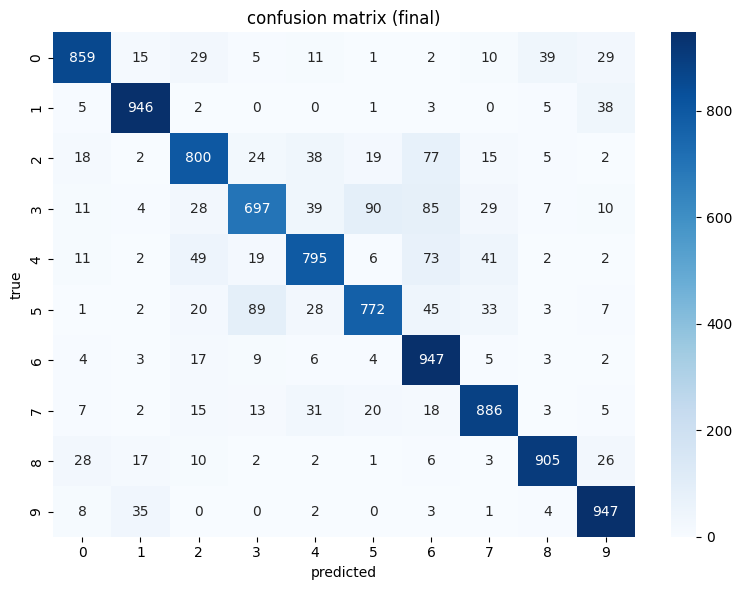

In [21]:
# final evaluation on test set after fine‑tuning
y_prob_final = model.predict(test_generator)
y_true       = np.argmax(y_test, axis=1)
y_pred_final = np.argmax(y_prob_final, axis=1)

# compute metrics
acc_final       = accuracy_score(y_true, y_pred_final)
f1_macro_final  = f1_score(y_true, y_pred_final, average='macro')
f1_weighted_final = f1_score(y_true, y_pred_final, average='weighted')
y_bin_final     = to_categorical(y_true, NUM_CLASSES)
auc_macro_final = roc_auc_score(y_bin_final, y_prob_final, multi_class='ovr', average='macro')
auc_micro_final = roc_auc_score(y_bin_final, y_prob_final, multi_class='ovr', average='micro')

# print summary
print(f"final accuracy        : {acc_final:.4f}")
print(f"final f1 (macro)      : {f1_macro_final:.4f}")
print(f"final f1 (weighted)   : {f1_weighted_final:.4f}")
print(f"final auc‑roc (macro) : {auc_macro_final:.4f}")
print(f"final auc‑roc (micro) : {auc_micro_final:.4f}\n")

# detailed classification report
print("final classification report:")
print(classification_report(
    y_true, y_pred_final,
    target_names=CLASS_NAMES,
    zero_division=0
))

# plot and save confusion matrix
cm_final = confusion_matrix(y_true, y_pred_final)
plt.figure(figsize=(8,6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('predicted')
plt.ylabel('true')
plt.title('confusion matrix (final)')
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "confusion_matrix_final.jpg"),
    dpi=300,
    format="jpg"
)
plt.show()

In [22]:
# save final fine‑tuned model
final_model_path = os.path.join(MODELS_DIR, "mobilenet_finetuned.keras")
model.save(final_model_path)
print(f"saved fine‑tuned model to {final_model_path}")

saved fine‑tuned model to outputs/models/mobilenet_finetuned.keras
